In [50]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd 
import os

In [25]:
analysis_modalidades = pd.read_parquet("../../bronze/modalidades_olympics/modalidades_olympics.parquet")


In [26]:
analysis_modalidades

,result_id,event_title,edition,edition_id,sport,result_date,result_location,result_participants,result_format,result_detail,result_description,event,tag,sport_code,sport_url
0,40000.0,"Individual, Men",1900 Summer Olympics,2.0,Golf,2 October 1900,"Golf de Compiègne, Compiègne",12 from 3 countries,36 holes stroke play,na,"Charles Sands, of the St. Andrews Golf Club in...",NaN,NaN,NaN,NaN
1,925229.0,"Individual, Handicap, Men",1900 Summer Olympics,2.0,Golf,3 October 1900,"Golf de Compiègne, Compiègne",19 from 4 countries,18 holes stroke play with handicaps.,na,"Al Lambert won the handicap event, playing off...",NaN,NaN,NaN,NaN
2,40001.0,"Individual, Women",1900 Summer Olympics,2.0,Golf,3 October 1900,"Golf de Compiègne, Compiègne",10 from 3 countries,9 holes stroke play,na,The ladies’ event took place the day after the...,NaN,NaN,NaN,NaN
3,925231.0,"Individual, Professional, Men",1900 Summer Olympics,2.0,Golf,3 October 1900,"Golf de Compiègne, Compiègne",2 from 1 countries,36 holes stroke play.,na,Chevalier and Phillips were local professional...,NaN,NaN,NaN,NaN
4,926022.0,Individual (Second Flight Consolation Champion...,1904 Summer Olympics,3.0,Golf,22 – 25 September 1904,"Glen Echo Country Club, Normandy",16 from 1 countries,Single-elimination tournament.,na,na,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7718,NaN,NaN,NaN,NaN,Wrestling,NaN,NaN,NaN,NaN,NaN,NaN,Men's Freestyle 65kg,wrestling,WRE,https://olympics.com/en/paris-2024/sports/wres...
7719,NaN,NaN,NaN,NaN,Wrestling,NaN,NaN,NaN,NaN,NaN,NaN,Men's Freestyle 74kg,wrestling,WRE,https://olympics.com/en/paris-2024/sports/wres...
7720,NaN,NaN,NaN,NaN,Wrestling,NaN,NaN,NaN,NaN,NaN,NaN,Men's Freestyle 86kg,wrestling,WRE,https://olympics.com/en/paris-2024/sports/wres...
7721,NaN,NaN,NaN,NaN,Wrestling,NaN,NaN,NaN,NaN,NaN,NaN,Men's Freestyle 97kg,wrestling,WRE,https://olympics.com/en/paris-2024/sports/wres...


In [27]:
analysis_modalidades.columns

Index(['result_id', 'event_title', 'edition', 'edition_id', 'sport',
       'result_date', 'result_location', 'result_participants',
       'result_format', 'result_detail', 'result_description', 'event', 'tag',
       'sport_code', 'sport_url'],
      dtype='str')

In [28]:
analysis_modalidades.drop(columns=['result_id', "event_title",'edition_id', 
       'result_date', 'result_location', 'result_participants',
       'result_format', 'result_detail', 'result_description', 'event', 'tag',
       'sport_code', 'sport_url'],inplace=True)

In [29]:
analysis_modalidades

,edition,sport
0,1900 Summer Olympics,Golf
1,1900 Summer Olympics,Golf
2,1900 Summer Olympics,Golf
3,1900 Summer Olympics,Golf
4,1904 Summer Olympics,Golf
...,...,...
7718,NaN,Wrestling
7719,NaN,Wrestling
7720,NaN,Wrestling
7721,NaN,Wrestling


In [30]:
analysis_modalidades["edition"] = analysis_modalidades["edition"].fillna("2024 Paris Summer Olympics")

In [31]:
analysis_modalidades

,edition,sport
0,1900 Summer Olympics,Golf
1,1900 Summer Olympics,Golf
2,1900 Summer Olympics,Golf
3,1900 Summer Olympics,Golf
4,1904 Summer Olympics,Golf
...,...,...
7718,2024 Paris Summer Olympics,Wrestling
7719,2024 Paris Summer Olympics,Wrestling
7720,2024 Paris Summer Olympics,Wrestling
7721,2024 Paris Summer Olympics,Wrestling


In [32]:
analysis_modalidades_processed = analysis_modalidades.drop_duplicates(subset=["edition","sport"])

In [33]:
analysis_modalidades_processed

,edition,sport
0,1900 Summer Olympics,Golf
4,1904 Summer Olympics,Golf
15,2020 Summer Olympics,Golf
17,2016 Summer Olympics,Golf
19,2012 Summer Olympics,Judo
...,...,...
7688,2024 Paris Summer Olympics,Triathlon
7691,2024 Paris Summer Olympics,Volleyball
7693,2024 Paris Summer Olympics,Water Polo
7695,2024 Paris Summer Olympics,Weightlifting


In [ ]:
analysis_modalidades_processed["edition"].str.strip()
analysis_modalidades_processed["sport"].str.strip()

0                Golf
4                Golf
15               Golf
17               Golf
19               Judo
            ...      
7688        Triathlon
7691       Volleyball
7693       Water Polo
7695    Weightlifting
7705        Wrestling
Name: sport, Length: 1183, dtype: str

In [ ]:
analysis_modalidades_processed["edition"].value_counts()

edition
2020 Summer Olympics          49
2024 Paris Summer Olympics    45
2008 Summer Olympics          42
2016 Summer Olympics          41
2012 Summer Olympics          39
2004 Summer Olympics          39
2000 Summer Olympics          39
1992 Summer Olympics          36
1996 Summer Olympics          36
1988 Summer Olympics          34
1900 Summer Olympics          32
1984 Summer Olympics          30
1920 Summer Olympics          30
1936 Summer Olympics          30
1972 Summer Olympics          29
1924 Summer Olympics          27
1964 Summer Olympics          26
1976 Summer Olympics          26
1980 Summer Olympics          26
1908 Summer Olympics          26
1952 Summer Olympics          26
1948 Summer Olympics          25
1968 Summer Olympics          25
1928 Summer Olympics          23
1932 Summer Olympics          23
1960 Summer Olympics          22
1956 Summer Olympics          22
1912 Summer Olympics          21
1904 Summer Olympics          20
2006 Winter Olympics          15
20

In [48]:
analysis_modalidades_processed_ready = analysis_modalidades_processed['edition'].value_counts().rename_axis('edition').reset_index(name='count')

In [49]:
analysis_modalidades_processed_ready

,edition,count
0,2020 Summer Olympics,49
1,2024 Paris Summer Olympics,45
2,2008 Summer Olympics,42
3,2016 Summer Olympics,41
4,2012 Summer Olympics,39
5,2004 Summer Olympics,39
6,2000 Summer Olympics,39
7,1992 Summer Olympics,36
8,1996 Summer Olympics,36
9,1988 Summer Olympics,34


In [51]:
analysis_modalidades_processed_ready.to_csv("./modalidades_olympics_summary.csv")

In [56]:
def criacao_metadados(path:str, data:list):
    if(os.path.exists(path)):
        pass
    with open(path,"w",encoding="UTF-8") as f:
        json.dump(data,f,ensure_ascii=False,indent=4)

def criar_grafico_50_top(data,string):
    plt.figure(figsize=(10,30))
    plt.barh(data["edition"], data[string])
    plt.gca().invert_yaxis()
    plt.xlabel("Olimpiadas")
    plt.title("Top 50 Olimpiadas com mais modalidades")
    plt.tight_layout()
    plt.savefig("modalidades_olympics_summary_plot.png")

In [57]:
metadata_modalidades = [
    {
        "arquivo": "modalidades_olympics_summary.csv",
        "descricao": "Dados de quantas modalidades há por olimpíada",
        "formato": "csv",
        "delimitador": ",",
        "codificacao": "latin1",
        "quantidade_linhas": "55",
        "dataset": "modalidades_olympics_summary.csv",
        "colunas": [
            {
                "nome": "edition",
                "tipo_dado": "string",
                "descricao": "Ano da edição dos Jogos Olímpicos"
            },
            {
                "nome": "count",
                "tipo_dado": "int64",
                "descricao": "Quantidade de modalidades em sua totalidade nas olimpiadas"
            }
        ]
    }
]

In [58]:
criacao_metadados("./modalidades_olympics_summary.json",metadata_modalidades)

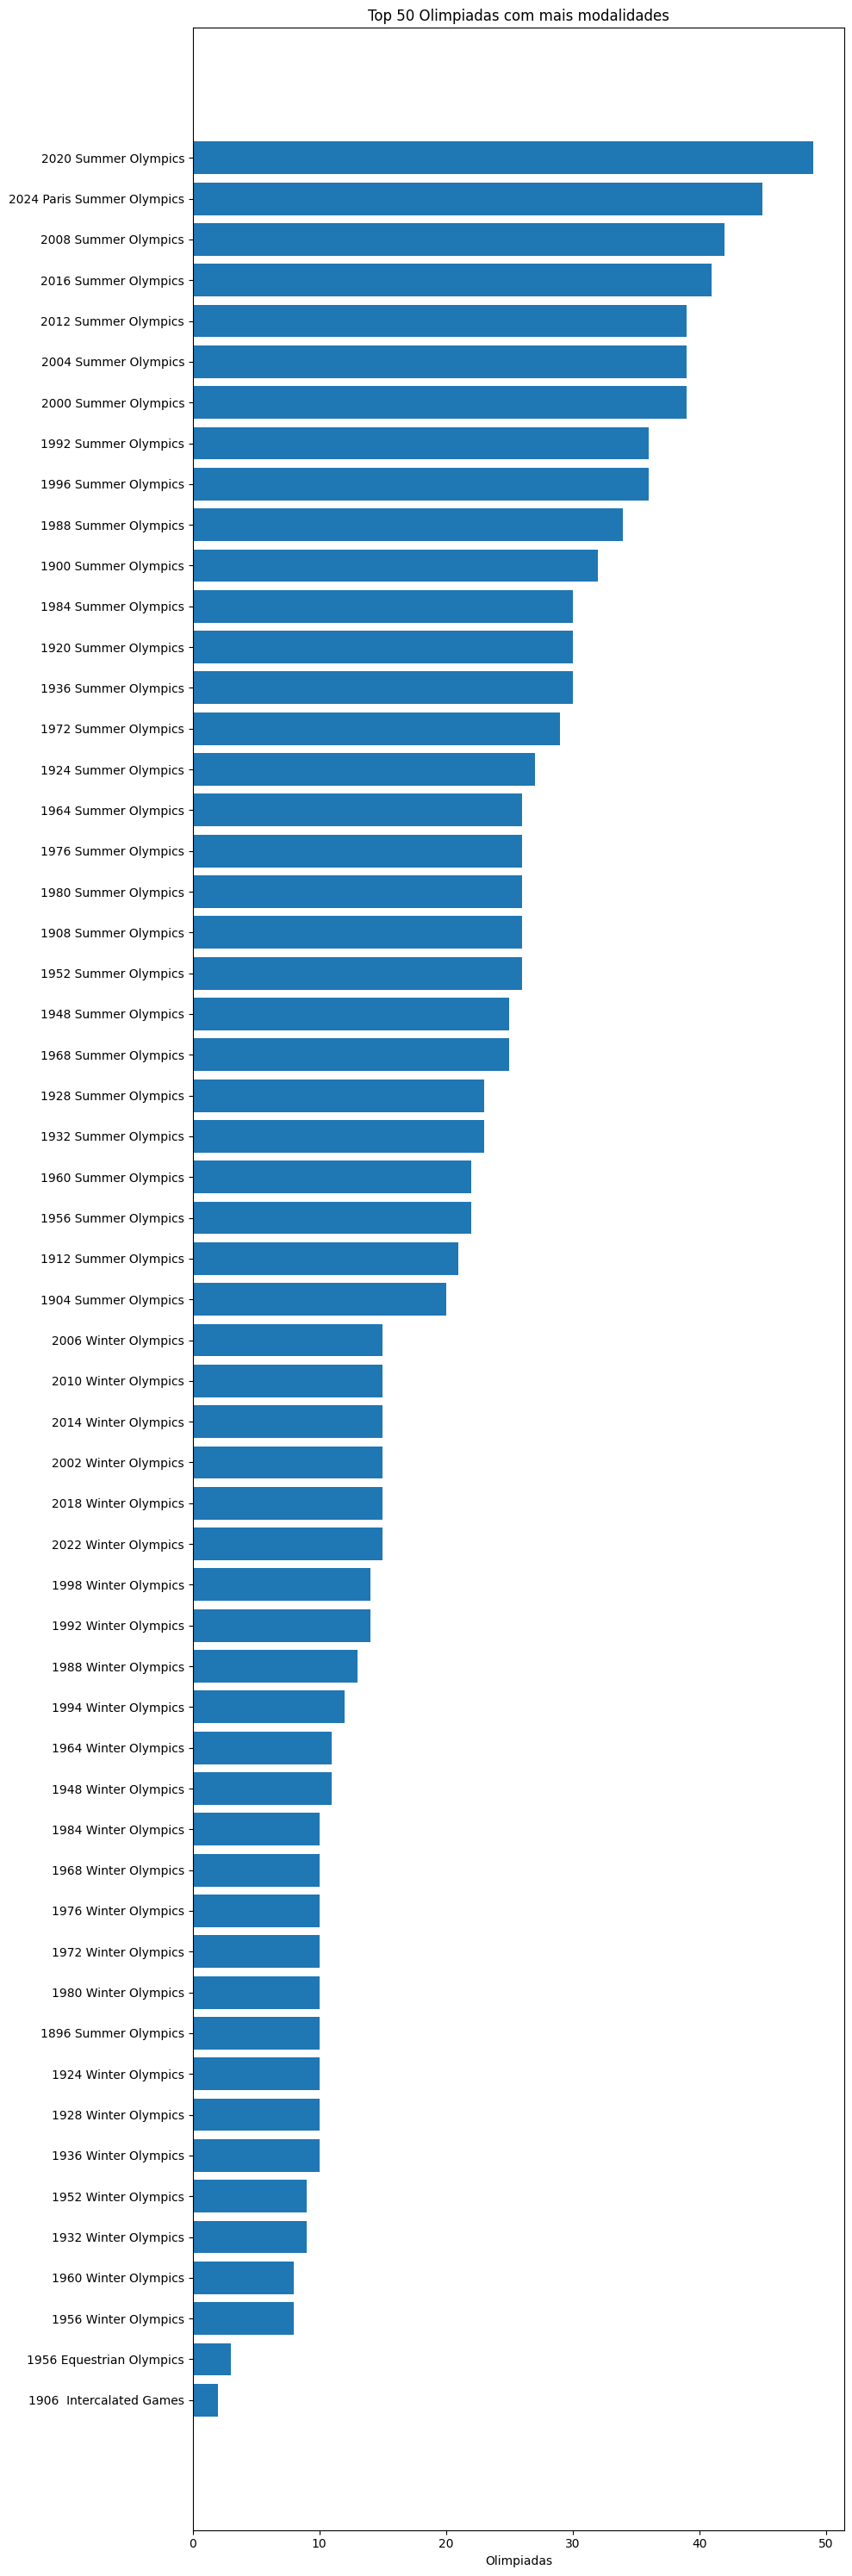

In [59]:
criar_grafico_50_top(analysis_modalidades_processed_ready,"count")